# Adult: Preprocessing, Inprocessing, and Postprocessing Comparison

This notebook mirrors the COMPAS processing-method analysis on the Adult dataset.
It compares:
- **Preprocessing**: uniform sampling vs reweighted sampling
- **Inprocessing**: LinUCB vs GroupAwareDPLinUCB
- **Postprocessing**: available only if a postprocessing bundle exists

The plots focus on the post-exploration region so the early rounds do not dominate the scale.

## Import Required Libraries

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from fair_bandits.config import build_config
from fair_bandits.metrics.fairness import equalized_odds_gap
from fair_bandits.metrics.temporal import aggregate_temporal_over_seeds

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (16, 12)
ZOOM_START = 250

## Configuration and Data Loading

In [2]:
CFG = build_config("full")
DATASET_NAME = "ADULT"
SENSITIVE_ATTR = "sex"  # switch to "race" to analyze the other Adult split
PREPROCESSINGS = ["uniform", "reweigh_group_label"]
RESULTS_ROOT = CFG.results_dir / "adult"
POSTPROC_DIR = CFG.results_dir / "adult_postprocessing"

print("Run mode:", CFG.run_mode)
print("Dataset:", DATASET_NAME)
print("Sensitive attribute:", SENSITIVE_ATTR)
print("Zoom start:", ZOOM_START)
print("Results root:", RESULTS_ROOT)
print("Postprocessing directory exists:", POSTPROC_DIR.exists())

Run mode: full
Dataset: ADULT
Sensitive attribute: sex
Zoom start: 250
Results root: results\full\adult
Postprocessing directory exists: True


## Load Adult Bandit Logs and Compute EO-gap

In [3]:
def get_run_dir(preprocessing: str) -> Path:
    return RESULTS_ROOT / f"sensitive_{SENSITIVE_ATTR}" / preprocessing


def compute_eo_gap_temporal(logs_df: pd.DataFrame) -> pd.Series:
    """Compute EO-gap over time in one pass.

    This avoids recomputing the full prefix for every round.
    """
    df = logs_df.sort_values("t").reset_index(drop=True)
    groups = df["group"].astype(str).to_numpy()
    y_true = df["y_true"].to_numpy(dtype=int)
    y_hat = df["action"].to_numpy(dtype=int)

    uniq_groups = np.unique(groups)
    pos_total = {g: 0 for g in uniq_groups}
    neg_total = {g: 0 for g in uniq_groups}
    tp = {g: 0 for g in uniq_groups}
    fp = {g: 0 for g in uniq_groups}

    eo_gaps = np.empty(len(df), dtype=float)
    for i, (g, yt, yh) in enumerate(zip(groups, y_true, y_hat)):
        if yt == 1:
            pos_total[g] += 1
            if yh == 1:
                tp[g] += 1
        else:
            neg_total[g] += 1
            if yh == 1:
                fp[g] += 1

        tpr_vals = [tp[gg] / pos_total[gg] if pos_total[gg] > 0 else 0.0 for gg in uniq_groups]
        fpr_vals = [fp[gg] / neg_total[gg] if neg_total[gg] > 0 else 0.0 for gg in uniq_groups]
        eo_gaps[i] = max(max(tpr_vals) - min(tpr_vals), max(fpr_vals) - min(fpr_vals))

    return pd.Series(eo_gaps, index=df["t"].to_numpy())


all_logs = []
for preprocessing in PREPROCESSINGS:
    run_dir = get_run_dir(preprocessing)
    logs_path = run_dir / "logs.csv"
    if not logs_path.exists():
        print(f"Missing logs: {logs_path}")
        continue

    logs = pd.read_csv(logs_path)
    logs_with_eo = []
    for (policy, seed), group_data in logs.groupby(["policy", "seed"]):
        group_data = group_data.sort_values("t").reset_index(drop=True).copy()
        group_data["eo_gap"] = compute_eo_gap_temporal(group_data).to_numpy()
        logs_with_eo.append(group_data)

    logs = pd.concat(logs_with_eo, ignore_index=True)
    all_logs.append(logs)
    print(f"Loaded {preprocessing}: {len(logs)} rows from {logs_path}")

if all_logs:
    logs_df = pd.concat(all_logs, ignore_index=True)
    print("Combined rows:", len(logs_df))
    display(logs_df[["t", "policy", "preprocessing", "seed", "dp_gap", "eo_gap"]].head())
else:
    raise FileNotFoundError("No Adult logs were found in the expected results directories.")

Loaded uniform: 3000000 rows from results\full\adult\sensitive_sex\uniform\logs.csv
Loaded reweigh_group_label: 3000000 rows from results\full\adult\sensitive_sex\reweigh_group_label\logs.csv
Combined rows: 6000000


,t,policy,preprocessing,seed,dp_gap,eo_gap
0,1,GroupAwareDPLinUCB,uniform,42,0.00,0.000000
1,2,GroupAwareDPLinUCB,uniform,42,0.00,0.000000
2,3,GroupAwareDPLinUCB,uniform,42,0.00,0.000000
3,4,GroupAwareDPLinUCB,uniform,42,0.25,0.333333
4,5,GroupAwareDPLinUCB,uniform,42,0.20,0.250000


## 1. Preprocessing: Uniform vs Reweighted Sampling

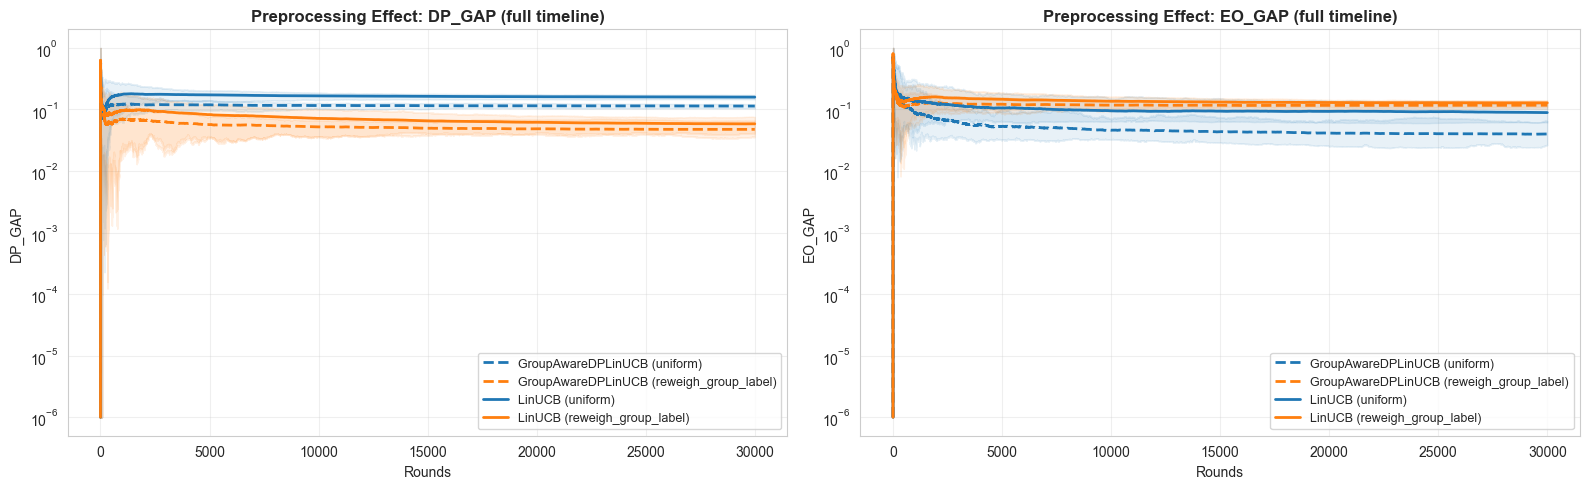

In [4]:
def plot_preprocessing_effect(logs_df: pd.DataFrame):
    zoom_start = globals().get("ZOOM_START", 250)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    policies = sorted(logs_df["policy"].unique())
    colors = {"uniform": "#1f77b4", "reweigh_group_label": "#ff7f0e"}

    small_eps = 1e-6

    for ax, metric_name in zip(axes, ["dp_gap", "eo_gap"]):
        for policy in policies:
            for preprocessing in PREPROCESSINGS:
                subset = logs_df[(logs_df["policy"] == policy) & (logs_df["preprocessing"] == preprocessing)]
                agg = aggregate_temporal_over_seeds(
                    subset,
                    value_cols=[metric_name],
                    group_cols=["preprocessing"],
                    t_col="t",
                    seed_col="seed",
                    alpha=0.05,
                ).sort_values("t")
                if agg.empty:
                    continue

                mean = agg[f"{metric_name}_mean"].to_numpy(dtype=float)
                low = agg[f"{metric_name}_low"].to_numpy(dtype=float)
                high = agg[f"{metric_name}_high"].to_numpy(dtype=float)

                mean = np.clip(mean, small_eps, None)
                low = np.clip(low, small_eps, None)
                high = np.clip(high, small_eps, None)

                linestyle = "-" if policy == "LinUCB" else "--"
                ax.plot(
                    agg["t"],
                    mean,
                    label=f"{policy} ({preprocessing})",
                    color=colors[preprocessing],
                    linestyle=linestyle,
                    linewidth=2,
                )
                ax.fill_between(
                    agg["t"],
                    low,
                    high,
                    color=colors[preprocessing],
                    alpha=0.1,
                )

        ax.set_xlabel("Rounds")
        ax.set_ylabel(metric_name.upper())
        ax.set_title(f"Preprocessing Effect: {metric_name.upper()} (full timeline)", fontweight="bold")
        ax.set_yscale('log')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


fig_preproc = plot_preprocessing_effect(logs_df)
Path("results/dev/final_figures").mkdir(parents=True, exist_ok=True)
plt.savefig("results/dev/final_figures/adult_preprocessing_effect.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. Inprocessing: LinUCB vs GroupAwareDPLinUCB

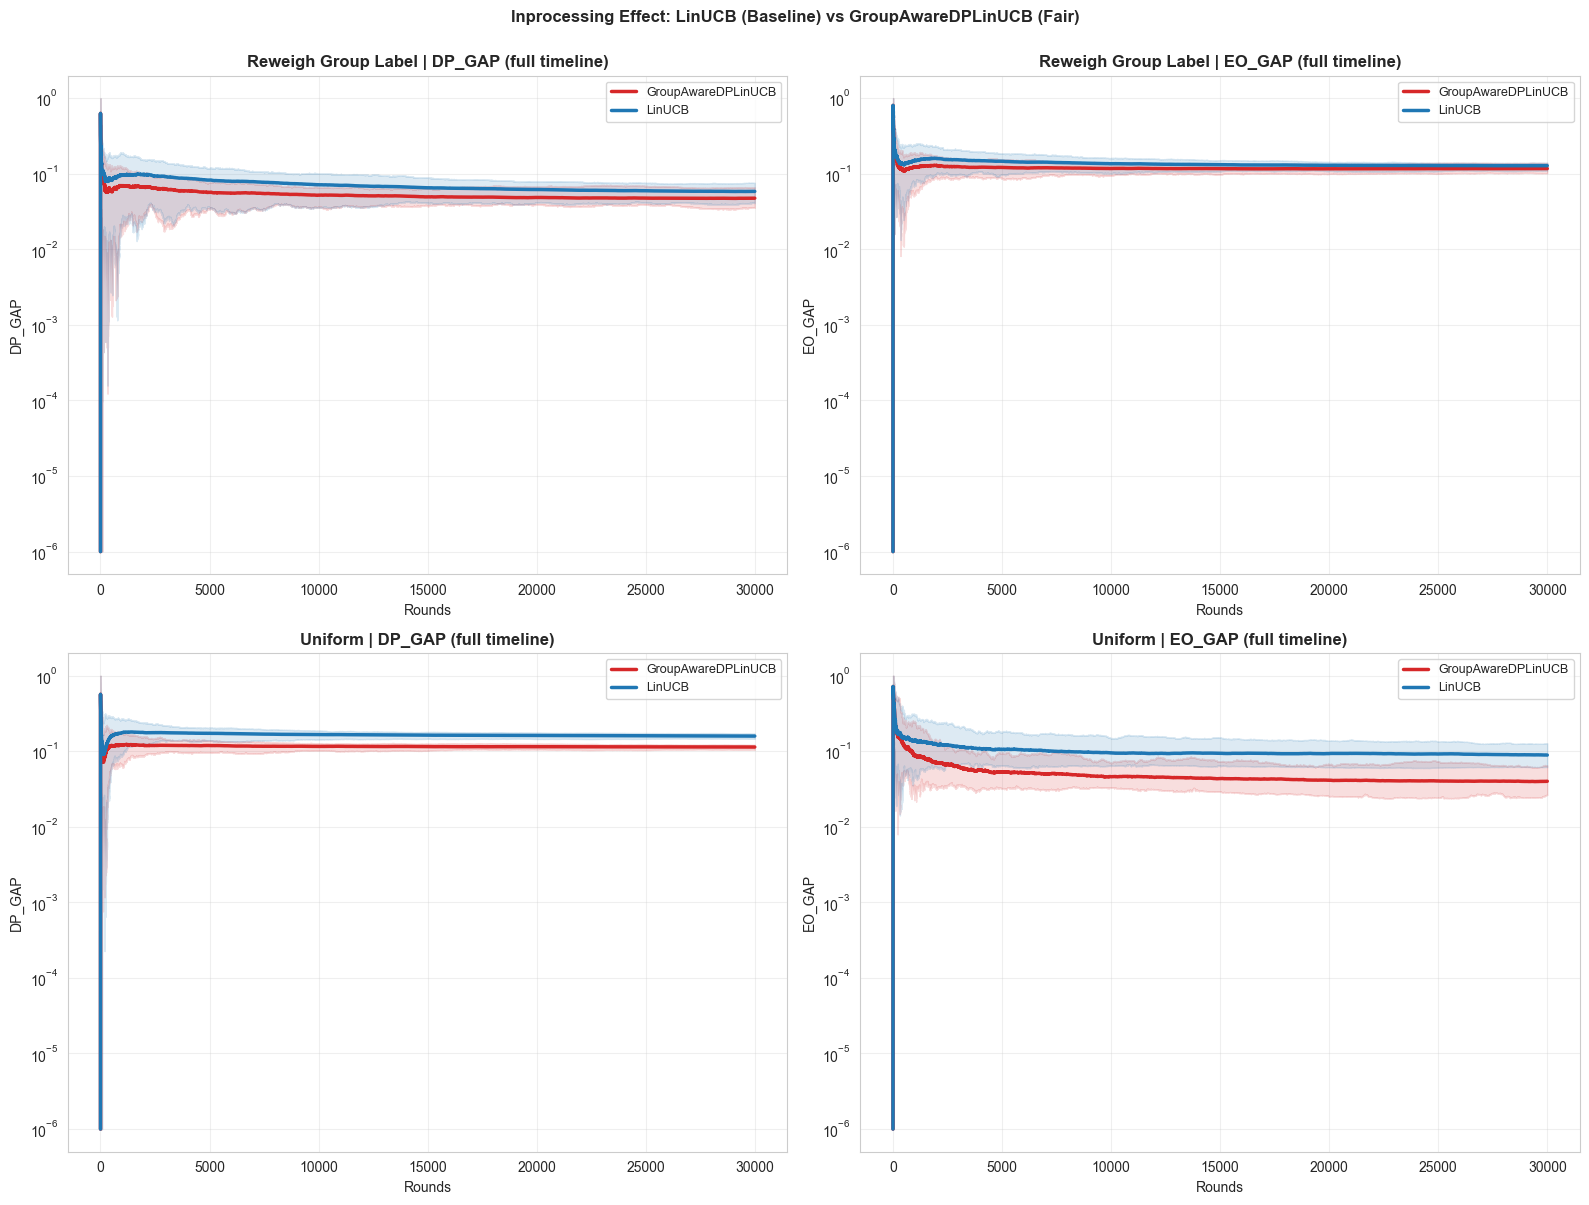

In [5]:
def plot_inprocessing_effect(logs_df: pd.DataFrame):
    zoom_start = globals().get("ZOOM_START", 250)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(
        "Inprocessing Effect: LinUCB (Baseline) vs GroupAwareDPLinUCB (Fair)",
        fontweight="bold",
        y=1.00,
    )

    preprocessings = sorted(logs_df["preprocessing"].unique())
    policies = sorted(logs_df["policy"].unique())
    colors = {"LinUCB": "#1f77b4", "GroupAwareDPLinUCB": "#d62728"}

    small_eps = 1e-6

    for row, preprocessing in enumerate(preprocessings):
        for col, metric_name in enumerate(["dp_gap", "eo_gap"]):
            ax = axes[row, col]
            subset = logs_df[logs_df["preprocessing"] == preprocessing]
            for policy in policies:
                policy_data = subset[subset["policy"] == policy]
                agg = aggregate_temporal_over_seeds(
                    policy_data,
                    value_cols=[metric_name],
                    group_cols=["policy"],
                    t_col="t",
                    seed_col="seed",
                    alpha=0.05,
                ).sort_values("t")
                if agg.empty:
                    continue

                mean = agg[f"{metric_name}_mean"].to_numpy(dtype=float)
                low = agg[f"{metric_name}_low"].to_numpy(dtype=float)
                high = agg[f"{metric_name}_high"].to_numpy(dtype=float)

                mean = np.clip(mean, small_eps, None)
                low = np.clip(low, small_eps, None)
                high = np.clip(high, small_eps, None)

                ax.plot(agg["t"], mean, label=policy, color=colors.get(policy, "#1f77b4"), linewidth=2.5)
                ax.fill_between(agg["t"], low, high, color=colors.get(policy, "#1f77b4"), alpha=0.15)

            ax.set_xlabel("Rounds")
            ax.set_ylabel(metric_name.upper())
            ax.set_title(f"{preprocessing.replace('_', ' ').title()} | {metric_name.upper()} (full timeline)", fontweight="bold")
            ax.set_yscale('log')
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


fig_inproc = plot_inprocessing_effect(logs_df)
plt.savefig("results/dev/final_figures/adult_inprocessing_effect.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Postprocessing: With and Without Postprocessor

In [6]:
postproc_perseed = None
postproc_ci = None

postproc_candidates = [
    POSTPROC_DIR / "adult_postproc_perseed_long.csv",
    POSTPROC_DIR / "adult_postproc_ci_long.csv",
]
existing_postproc = [path for path in postproc_candidates if path.exists()]

if existing_postproc:
    print("Found Adult postprocessing files:")
    for path in existing_postproc:
        print(" -", path)

    perseed_path = POSTPROC_DIR / "adult_postproc_perseed_long.csv"
    ci_path = POSTPROC_DIR / "adult_postproc_ci_long.csv"

    if perseed_path.exists():
        postproc_perseed = pd.read_csv(perseed_path)
        print(f"Loaded per-seed postprocessing data: {len(postproc_perseed)} rows")

    if ci_path.exists():
        postproc_ci = pd.read_csv(ci_path)
        print(f"Loaded CI postprocessing data: {len(postproc_ci)} rows")
else:
    print("No Adult postprocessing bundle exists in the repository yet.")
    print("This section is kept as a placeholder so you can plug in postprocessing results later.")

Found Adult postprocessing files:
 - results\full\adult_postprocessing\adult_postproc_perseed_long.csv
 - results\full\adult_postprocessing\adult_postproc_ci_long.csv
Loaded per-seed postprocessing data: 4000 rows
Loaded CI postprocessing data: 80 rows


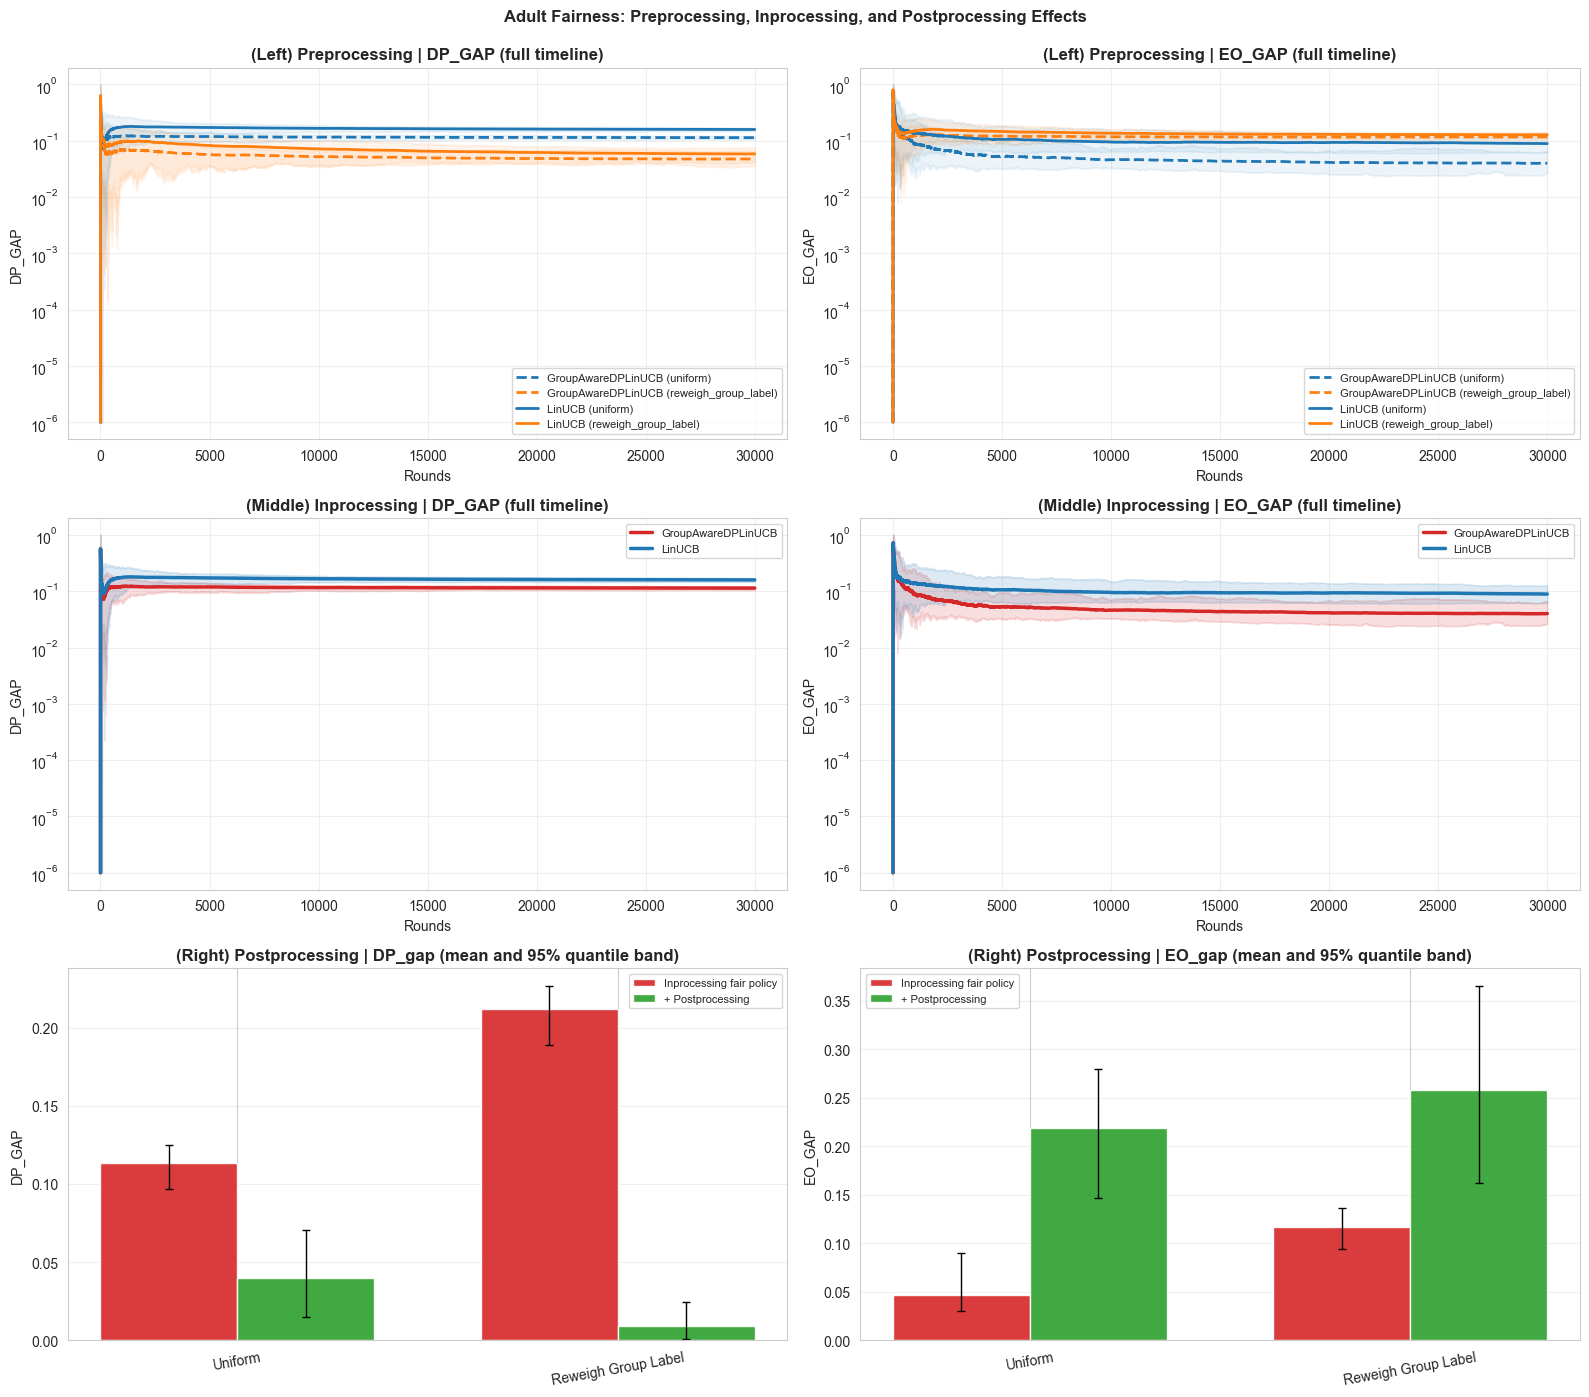

In [7]:
def plot_combined_processing_methods(logs_df: pd.DataFrame, postproc_perseed=None):
    zoom_start = globals().get("ZOOM_START", 250)
    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle(
        "Adult Fairness: Preprocessing, Inprocessing, and Postprocessing Effects",
        fontweight="bold",
        y=0.995,
    )

    policies = sorted(logs_df["policy"].unique())
    colors_preproc = {"uniform": "#1f77b4", "reweigh_group_label": "#ff7f0e"}
    colors_inproc = {"LinUCB": "#1f77b4", "GroupAwareDPLinUCB": "#d62728"}
    postproc_methods = ["GroupAwareDPLinUCB", "GroupAwareDPLinUCB_PostProc"]
    postproc_labels = {
        "GroupAwareDPLinUCB": "Inprocessing fair policy",
        "GroupAwareDPLinUCB_PostProc": "+ Postprocessing",
    }
    postproc_colors = {
        "GroupAwareDPLinUCB": "#d62728",
        "GroupAwareDPLinUCB_PostProc": "#2ca02c",
    }

    small_eps = 1e-6

    for col, metric_name in enumerate(["dp_gap", "eo_gap"]):
        ax = axes[0, col]
        for policy in policies:
            for preprocessing in PREPROCESSINGS:
                subset = logs_df[(logs_df["policy"] == policy) & (logs_df["preprocessing"] == preprocessing)]
                agg = aggregate_temporal_over_seeds(
                    subset,
                    value_cols=[metric_name],
                    group_cols=["preprocessing"],
                    t_col="t",
                    seed_col="seed",
                    alpha=0.05,
                ).sort_values("t")
                if agg.empty:
                    continue

                mean = agg[f"{metric_name}_mean"].to_numpy(dtype=float)
                low = agg[f"{metric_name}_low"].to_numpy(dtype=float)
                high = agg[f"{metric_name}_high"].to_numpy(dtype=float)

                mean = np.clip(mean, small_eps, None)
                low = np.clip(low, small_eps, None)
                high = np.clip(high, small_eps, None)

                ax.plot(agg["t"], mean, label=f"{policy} ({preprocessing})", color=colors_preproc[preprocessing], linestyle="-" if policy == "LinUCB" else "--", linewidth=2)
                ax.fill_between(agg["t"], low, high, color=colors_preproc[preprocessing], alpha=0.08)
        ax.set_xlabel("Rounds")
        ax.set_ylabel(metric_name.upper())
        ax.set_title(f"(Left) Preprocessing | {metric_name.upper()} (full timeline)", fontweight="bold")
        ax.set_yscale('log')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    for col, metric_name in enumerate(["dp_gap", "eo_gap"]):
        ax = axes[1, col]
        subset = logs_df[logs_df["preprocessing"] == "uniform"]
        for policy in policies:
            policy_data = subset[subset["policy"] == policy]
            agg = aggregate_temporal_over_seeds(
                policy_data,
                value_cols=[metric_name],
                group_cols=["policy"],
                t_col="t",
                seed_col="seed",
                alpha=0.05,
            ).sort_values("t")
            if agg.empty:
                continue

            mean = agg[f"{metric_name}_mean"].to_numpy(dtype=float)
            low = agg[f"{metric_name}_low"].to_numpy(dtype=float)
            high = agg[f"{metric_name}_high"].to_numpy(dtype=float)

            mean = np.clip(mean, small_eps, None)
            low = np.clip(low, small_eps, None)
            high = np.clip(high, small_eps, None)

            ax.plot(agg["t"], mean, label=policy, color=colors_inproc.get(policy, "#1f77b4"), linewidth=2.5)
            ax.fill_between(agg["t"], low, high, color=colors_inproc.get(policy, "#1f77b4"), alpha=0.15)
        ax.set_xlabel("Rounds")
        ax.set_ylabel(metric_name.upper())
        ax.set_title(f"(Middle) Inprocessing | {metric_name.upper()} (full timeline)", fontweight="bold")
        ax.set_yscale('log')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    metric_map = {"dp_gap": "DP_gap", "eo_gap": "EO_gap"}
    for col, metric_name in enumerate(["dp_gap", "eo_gap"]):
        ax = axes[2, col]
        metric_key = metric_map[metric_name]

        if postproc_perseed is None or postproc_perseed.empty:
            ax.text(
                0.5,
                0.5,
                "No Adult postprocessing bundle available",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=12,
            )
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f"(Right) Postprocessing | {metric_key}", fontweight="bold")
            continue

        subset = postproc_perseed.copy()
        if "sensitive" in subset.columns:
            subset = subset[subset["sensitive"].astype(str) == str(SENSITIVE_ATTR)]

        subset = subset[(subset["metric"] == metric_key) & (subset["method"].isin(postproc_methods))]

        if subset.empty:
            ax.text(
                0.5,
                0.5,
                f"No postprocessing rows found for {metric_key}",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=12,
            )
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f"(Right) Postprocessing | {metric_key}", fontweight="bold")
            continue

        summary = (
            subset.groupby(["preprocessing", "method"])["value"]
            .agg(
                mean="mean",
                q025=lambda s: s.quantile(0.025),
                q975=lambda s: s.quantile(0.975),
            )
            .reset_index()
        )

        preprocessings = [p for p in PREPROCESSINGS if p in summary["preprocessing"].unique()]
        if not preprocessings:
            ax.text(
                0.5,
                0.5,
                f"No preprocessing groups found for {metric_key}",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=12,
            )
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f"(Right) Postprocessing | {metric_key}", fontweight="bold")
            continue

        x = np.arange(len(preprocessings), dtype=float)
        width = 0.36

        for i, method in enumerate(postproc_methods):
            meth = summary[summary["method"] == method].set_index("preprocessing").reindex(preprocessings)
            means = meth["mean"].to_numpy(dtype=float)
            lows = meth["q025"].to_numpy(dtype=float)
            highs = meth["q975"].to_numpy(dtype=float)
            offsets = x + (i - 0.5) * width

            ax.bar(
                offsets,
                means,
                width=width,
                color=postproc_colors[method],
                alpha=0.9,
                label=postproc_labels[method],
            )

            yerr_low = means - lows
            yerr_high = highs - means
            ax.errorbar(
                offsets,
                means,
                yerr=np.vstack([yerr_low, yerr_high]),
                fmt="none",
                ecolor="black",
                capsize=3,
                linewidth=1,
            )

        ax.set_xticks(x)
        ax.set_xticklabels([p.replace("_", " ").title() for p in preprocessings], rotation=10)
        ax.set_ylabel(metric_name.upper())
        ax.set_title(f"(Right) Postprocessing | {metric_key} (mean and 95% quantile band)", fontweight="bold")
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    return fig


fig_combined = plot_combined_processing_methods(logs_df, postproc_perseed=postproc_perseed)
plt.savefig("results/dev/final_figures/adult_combined_processing_methods.png", dpi=300, bbox_inches="tight")
plt.show()

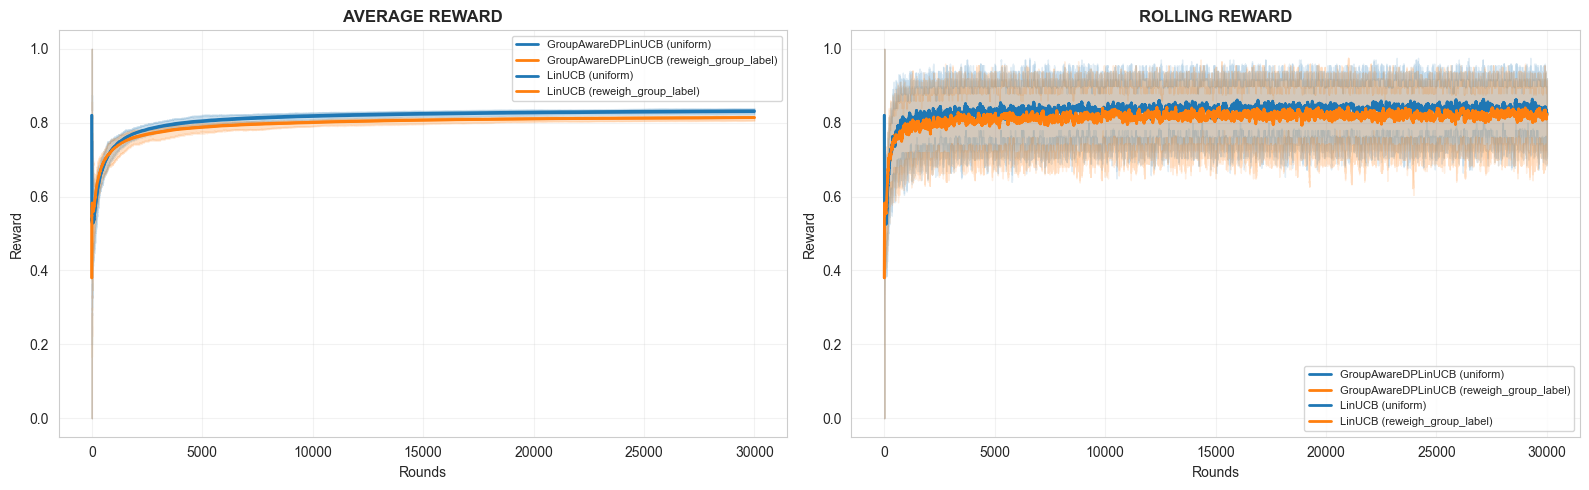

In [8]:
def plot_rewards_over_time(logs_df: pd.DataFrame):
    """Plot average and rolling rewards over time aggregated across seeds.

    Produces a two-panel figure: left = average reward, right = rolling reward.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    policies = sorted(logs_df["policy"].unique())
    colors_preproc = {"uniform": "#1f77b4", "reweigh_group_label": "#ff7f0e"}

    small_eps = 1e-9

    for col, metric_name in enumerate(["avg_reward", "rolling_reward"]):
        ax = axes[col]
        for policy in policies:
            for preprocessing in PREPROCESSINGS:
                subset = logs_df[(logs_df["policy"] == policy) & (logs_df["preprocessing"] == preprocessing)]
                agg = aggregate_temporal_over_seeds(
                    subset,
                    value_cols=[metric_name],
                    group_cols=["preprocessing"],
                    t_col="t",
                    seed_col="seed",
                    alpha=0.05,
                ).sort_values("t")

                if agg.empty:
                    continue

                mean = agg[f"{metric_name}_mean"].to_numpy(dtype=float)
                low = agg[f"{metric_name}_low"].to_numpy(dtype=float)
                high = agg[f"{metric_name}_high"].to_numpy(dtype=float)

                mean = np.clip(mean, small_eps, None)
                low = np.clip(low, small_eps, None)
                high = np.clip(high, small_eps, None)

                label = f"{policy} ({preprocessing})"
                ax.plot(agg["t"], mean, label=label, color=colors_preproc.get(preprocessing, "#333333"), linewidth=2)
                ax.fill_between(agg["t"], low, high, color=colors_preproc.get(preprocessing, "#333333"), alpha=0.12)

        ax.set_xlabel("Rounds")
        ax.set_ylabel("Reward")
        title_map = {"avg_reward": "Average Reward", "rolling_reward": "Rolling Reward"}
        ax.set_title(title_map.get(metric_name, metric_name).upper(), fontweight="bold")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.25)

    plt.tight_layout()
    return fig


fig_rewards = plot_rewards_over_time(logs_df)
plt.savefig("results/dev/final_figures/adult_rewards_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

## Key Insights and Analysis

In [ ]:
print("ADULT FAIRNESS INTERVENTION SUMMARY")

for policy in sorted(logs_df["policy"].unique()):
    print(f"\nPolicy: {policy}")
    for preprocessing in PREPROCESSINGS:
        subset = logs_df[(logs_df["policy"] == policy) & (logs_df["preprocessing"] == preprocessing)]
        if subset.empty:
            continue
        final_dp_gap = subset.groupby("seed")["dp_gap"].last().mean()
        final_eo_gap = subset.groupby("seed")["eo_gap"].last().mean()
        print(f"  {preprocessing:25s}: DP-gap={final_dp_gap:.4f}, EO-gap={final_eo_gap:.4f}")

print("\nPostprocessing:")
if existing_postproc:
    for path in existing_postproc:
        print(f"  Found {path.name}")
else:
    print("  No Adult postprocessing bundle was found; this section is intentionally a placeholder.")

print("\nSaved figures:")
print("  results/dev/final_figures/adult_preprocessing_effect.png")
print("  results/dev/final_figures/adult_inprocessing_effect.png")
print("  results/dev/final_figures/adult_combined_processing_methods.png")

ADULT FAIRNESS INTERVENTION SUMMARY

Policy: GroupAwareDPLinUCB
  uniform                  : DP-gap=0.1136, EO-gap=0.0401
  reweigh_group_label      : DP-gap=0.0475, EO-gap=0.1172

Policy: LinUCB
  uniform                  : DP-gap=0.1587, EO-gap=0.0890
  reweigh_group_label      : DP-gap=0.0585, EO-gap=0.1280

Postprocessing:
  Found adult_postproc_perseed_long.csv
  Found adult_postproc_ci_long.csv

Saved figures:
  results/dev/final_figures/adult_preprocessing_effect.png
  results/dev/final_figures/adult_inprocessing_effect.png
  results/dev/final_figures/adult_combined_processing_methods.png


In [10]:
# Run Adult postprocessing benchmark (mirrors COMPAS pipeline)
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from fair_bandits.data import load_adult
from fair_bandits.data.adult import to_binary_income
from fair_bandits.data.preprocessing import find_first_existing_column
from fair_bandits.policies import LinUCB, GroupAwareDPLinUCB
from fair_bandits.metrics.summary import summarize_metrics, mean_ci

# Postprocessing config
POSTPROC_TARGET_METRIC = "DP_gap"
POSTPROC_MAX_ACC_DROP = 0.01
POSTPROC_GRID_SIZE = 31
KEY_METRICS = [
    "accuracy",
    "DP_gap",
    "TPR_gap",
    "FPR_gap",
    "EO_gap",
    "PPV_gap",
    "UtilityGap",
    "CumulativeRegret",
]

RESULTS_DIR = POSTPROC_DIR
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def _frame_feature_df(df: pd.DataFrame, label_col: str, sensitive_col: str, drop_cols: list[str] | None = None) -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    data = df.copy()
    y = to_binary_income(data[label_col])
    group = data[sensitive_col].astype(str).fillna("Unknown")

    exclude = {label_col, sensitive_col}
    if drop_cols is not None:
        exclude.update(c for c in drop_cols if c in data.columns)

    X_df = data.drop(columns=[c for c in exclude if c in data.columns]).copy()

    for col in X_df.columns:
        if pd.api.types.is_numeric_dtype(X_df[col]):
            X_df[col] = pd.to_numeric(X_df[col], errors="coerce")
            fill_value = X_df[col].median() if X_df[col].notna().any() else 0.0
            X_df[col] = X_df[col].fillna(fill_value)
        else:
            X_df[col] = X_df[col].astype(str).fillna("Unknown")

    X_df = pd.get_dummies(X_df, drop_first=False)
    X_df = X_df.apply(pd.to_numeric, errors="coerce").fillna(0.0)

    return X_df, np.asarray(y, dtype=int), np.asarray(group, dtype=str)


def prepare_train_and_eval_matrices_adult(train_df: pd.DataFrame, eval_df: pd.DataFrame, sensitive_col: str):
    # Detect label column robustly
    label_col = find_first_existing_column(train_df, candidates=["income", "class", "target"], what="Adult label column")

    X_train_df, y_train, group_train = _frame_feature_df(train_df, label_col=label_col, sensitive_col=sensitive_col)
    X_eval_df, y_eval, group_eval = _frame_feature_df(eval_df, label_col=label_col, sensitive_col=sensitive_col)

    # Ensure consistent columns: reindex eval to train columns
    train_cols = X_train_df.columns.tolist()
    X_eval_df = X_eval_df.reindex(columns=train_cols, fill_value=0.0)

    X_train = X_train_df.to_numpy(dtype=float)
    X_eval = X_eval_df.to_numpy(dtype=float)

    # Lightweight standardization for numerical stability (fit on train)
    mu = X_train.mean(axis=0, keepdims=True)
    sigma = X_train.std(axis=0, keepdims=True)
    sigma[sigma < 1e-12] = 1.0
    X_train = (X_train - mu) / sigma
    X_eval = (X_eval - mu) / sigma

    return X_train, y_train, group_train, X_eval, y_eval, group_eval


def fit_bandit_policy_on_prefix(
    X_train: np.ndarray,
    y_train: np.ndarray,
    group_train: np.ndarray,
    idx_prefix: np.ndarray,
    method_name: str,
    cfg,
):
    d = int(X_train.shape[1])

    if method_name == "LinUCB":
        policy = LinUCB(d=d, alpha=cfg.alpha_linucb, lam=cfg.lambda_ridge)
    elif method_name == "GroupAwareDPLinUCB":
        policy = GroupAwareDPLinUCB(
            d=d,
            groups=group_train,
            alpha=cfg.alpha_linucb,
            lam=cfg.lambda_ridge,
            tau=cfg.dp_tau,
            lambda_fair=cfg.dp_lambda,
            beta_smooth=cfg.beta_smooth,
            min_group_count=cfg.min_group_count,
        )
    else:
        raise ValueError(f"Unsupported bandit method: {method_name}")

    for i in idx_prefix:
        x = X_train[int(i)]
        yt = int(y_train[int(i)])
        g = str(group_train[int(i)])
        a = int(policy.select(x, g))
        r = float(a == yt)
        policy.update(x, a, r, g)

    return policy


def predict_with_bandit_policy(policy, X_eval: np.ndarray, group_eval: np.ndarray) -> np.ndarray:
    preds = []
    for x, g in zip(X_eval, group_eval):
        preds.append(int(policy.select(x, str(g))))
    return np.asarray(preds, dtype=int)


def fit_supervised_prefix_model(
    X_prefix: np.ndarray,
    y_prefix: np.ndarray,
    method_name: str,
    seed: int,
):
    y_prefix = np.asarray(y_prefix, dtype=int)

    if np.unique(y_prefix).size < 2:
        clf = DummyClassifier(strategy="constant", constant=int(y_prefix[0]))
        clf.fit(X_prefix, y_prefix)
        return clf

    if method_name == "LogisticRegression":
        clf = LogisticRegression(max_iter=2000, solver="lbfgs", random_state=seed)
    elif method_name == "RandomForest":
        clf = RandomForestClassifier(n_estimators=400, random_state=seed, n_jobs=-1)
    else:
        raise ValueError(f"Unsupported supervised method: {method_name}")

    clf.fit(X_prefix, y_prefix)
    return clf


# Group-threshold postprocessor helpers (adapted from COMPAS notebook)

def fairlinucb_groupaware_scores(policy, x: np.ndarray, group: str) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    g = str(group)

    scores = np.zeros(policy.n_actions, dtype=np.float32)
    for a in range(policy.n_actions):
        theta = policy._theta(a)
        mean = float(theta @ x)
        var = float(x @ (policy.A_inv[a] @ x))
        ucb = mean + policy.alpha * np.sqrt(max(var, 0.0))
        penalty = policy._fair_penalty(g, a)
        scores[a] = ucb - penalty
    return scores


def fairlinucb_groupaware_margin(policy, X: np.ndarray, group: np.ndarray) -> np.ndarray:
    margins = []
    for x, g in zip(X, group):
        s = fairlinucb_groupaware_scores(policy, x, str(g))
        margins.append(float(s[1] - s[0]))
    return np.asarray(margins, dtype=float)


def predict_with_group_thresholds(policy, X: np.ndarray, group: np.ndarray, thresholds: dict[str, float]) -> np.ndarray:
    margins = fairlinucb_groupaware_margin(policy, X, group)
    preds = np.array([int(m >= thresholds[str(g)]) for m, g in zip(margins, group)], dtype=int)
    return preds


def fit_group_threshold_postprocessor(
    policy,
    X_cal: np.ndarray,
    y_cal: np.ndarray,
    group_cal: np.ndarray,
    *,
    target_metric: str = POSTPROC_TARGET_METRIC,
    max_acc_drop: float = POSTPROC_MAX_ACC_DROP,
    grid_size: int = POSTPROC_GRID_SIZE,
):
    X_cal = np.asarray(X_cal)
    y_cal = np.asarray(y_cal).astype(int)
    group_cal = np.asarray(group_cal).astype(str)

    uniq_groups = sorted(np.unique(group_cal).tolist())
    if len(uniq_groups) != 2:
        raise ValueError(f"This version expects exactly 2 groups, got: {uniq_groups}")

    raw_preds = predict_with_bandit_policy(policy, X_cal, group_cal)
    raw_reward = (raw_preds == y_cal).astype(float)
    raw_metrics = summarize_metrics(y_true=y_cal, y_hat=raw_preds, group=group_cal, reward=raw_reward, oracle_reward=1.0)
    baseline_acc = float(raw_metrics["accuracy"])

    margins = fairlinucb_groupaware_margin(policy, X_cal, group_cal)
    lo, hi = np.quantile(margins, [0.05, 0.95])
    grid = np.linspace(lo, hi, int(grid_size))
    grid = np.unique(np.concatenate([grid, [0.0]]))

    g1, g2 = uniq_groups
    is_g1 = (group_cal == g1)

    best = None
    search_rows = []

    for t1, t2 in product(grid, repeat=2):
        thr_vec = np.where(is_g1, t1, t2)
        y_hat = (margins >= thr_vec).astype(int)
        reward = (y_hat == y_cal).astype(float)
        met = summarize_metrics(y_true=y_cal, y_hat=y_hat, group=group_cal, reward=reward, oracle_reward=1.0)

        row = {f"threshold_{g1}": float(t1), f"threshold_{g2}": float(t2), **met}
        search_rows.append(row)

        acc = float(met["accuracy"])
        fairness_value = float(met[target_metric])

        feasible = acc >= baseline_acc - max_acc_drop
        if not feasible:
            continue

        score = (fairness_value, -acc)
        if best is None or score < best["score"]:
            best = {"thresholds": {g1: float(t1), g2: float(t2)}, "metrics": met, "score": score}

    if best is None:
        best = {"thresholds": {g1: 0.0, g2: 0.0}, "metrics": raw_metrics, "score": (float(raw_metrics[target_metric]), -baseline_acc)}

    search_df = pd.DataFrame(search_rows).sort_values([target_metric, "accuracy"], ascending=[True, False]).reset_index(drop=True)

    return best["thresholds"], search_df, raw_metrics, best["metrics"]


def evaluate_predictions_to_long_rows(
    *,
    dataset: str,
    sensitive: str,
    preprocessing: str,
    horizon: int,
    seed: int,
    method: str,
    y_true: np.ndarray,
    y_hat: np.ndarray,
    group: np.ndarray,
):
    reward = (np.asarray(y_true, dtype=int) == np.asarray(y_hat, dtype=int)).astype(float)
    met = summarize_metrics(y_true=np.asarray(y_true, dtype=int), y_hat=np.asarray(y_hat, dtype=int), group=np.asarray(group).astype(str), reward=reward, oracle_reward=1.0)

    rows = []
    for metric in KEY_METRICS:
        rows.append({
            "dataset": dataset,
            "sensitive": sensitive,
            "preprocessing": preprocessing,
            "horizon": int(horizon),
            "seed": int(seed),
            "method": method,
            "metric": metric,
            "value": float(met[metric]),
            "n_eval": int(len(y_true)),
        })
    return rows


def summarize_long_with_ci(long_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    group_cols = ["dataset", "sensitive", "preprocessing", "horizon", "method", "metric"]
    for keys, sub in long_df.groupby(group_cols):
        mu, lo, hi = mean_ci(sub["value"].to_numpy(dtype=float), alpha=0.05)
        rows.append({**dict(zip(group_cols, keys)), "mean": mu, "ci_low": lo, "ci_high": hi, "n_seeds": int(sub["seed"].nunique())})
    return pd.DataFrame(rows).sort_values(group_cols).reset_index(drop=True)


def run_adult_postprocessing_benchmark(*, cfg, sensitive_list: list[str], preprocessing_modes: list[str], horizons: list[int], seeds: list[int]):
    rows = []
    search_tables = {}

    df_raw = load_adult()

    for sensitive in sensitive_list:
        for preprocessing in preprocessing_modes:
            for seed in seeds:
                outer_train_df, test_df = train_test_split(df_raw, test_size=0.2, random_state=int(seed), stratify=None)

                bandit_train_df, cal_df = train_test_split(outer_train_df, test_size=0.2, random_state=int(seed), stratify=None)

                X_train, y_train, group_train, X_cal, y_cal, group_cal = prepare_train_and_eval_matrices_adult(bandit_train_df, cal_df, sensitive_col=sensitive)
                X_train_2, y_train_2, group_train_2, X_test, y_test, group_test = prepare_train_and_eval_matrices_adult(bandit_train_df, test_df, sensitive_col=sensitive)

                if X_train.shape != X_train_2.shape or not np.array_equal(y_train, y_train_2):
                    raise ValueError("Train matrices differ across calibration/test preparation; check preprocessing logic.")

                sampling_probs = None
                if preprocessing == "reweigh_group_label":
                    from fair_bandits.data.preprocessing import make_group_label_sampling_probs

                    sampling_probs = make_group_label_sampling_probs(group_train, y_train)

                for horizon in horizons:
                    rng = np.random.default_rng(int(seed))
                    idx_prefix = rng.choice(len(X_train), size=int(horizon), replace=True, p=sampling_probs)

                    lin_policy = fit_bandit_policy_on_prefix(X_train=X_train, y_train=y_train, group_train=group_train, idx_prefix=idx_prefix, method_name="LinUCB", cfg=cfg)
                    fair_policy = fit_bandit_policy_on_prefix(X_train=X_train, y_train=y_train, group_train=group_train, idx_prefix=idx_prefix, method_name="GroupAwareDPLinUCB", cfg=cfg)

                    lr_clf = fit_supervised_prefix_model(X_prefix=X_train[idx_prefix], y_prefix=y_train[idx_prefix], method_name="LogisticRegression", seed=int(seed))
                    rf_clf = fit_supervised_prefix_model(X_prefix=X_train[idx_prefix], y_prefix=y_train[idx_prefix], method_name="RandomForest", seed=int(seed))

                    lin_test_pred = predict_with_bandit_policy(lin_policy, X_test, group_test)
                    fair_test_pred = predict_with_bandit_policy(fair_policy, X_test, group_test)
                    lr_test_pred = lr_clf.predict(X_test).astype(int)
                    rf_test_pred = rf_clf.predict(X_test).astype(int)

                    thresholds, search_df, raw_cal_metrics, best_cal_metrics = fit_group_threshold_postprocessor(fair_policy, X_cal, y_cal, group_cal, target_metric=POSTPROC_TARGET_METRIC, max_acc_drop=POSTPROC_MAX_ACC_DROP, grid_size=POSTPROC_GRID_SIZE)
                    post_test_pred = predict_with_group_thresholds(fair_policy, X_test, group_test, thresholds=thresholds)

                    search_key = (sensitive, preprocessing, seed, horizon)
                    search_tables[search_key] = search_df.copy()

                    rows.extend(evaluate_predictions_to_long_rows(dataset=DATASET_NAME, sensitive=sensitive, preprocessing=preprocessing, horizon=horizon, seed=seed, method="LinUCB", y_true=y_test, y_hat=lin_test_pred, group=group_test))
                    rows.extend(evaluate_predictions_to_long_rows(dataset=DATASET_NAME, sensitive=sensitive, preprocessing=preprocessing, horizon=horizon, seed=seed, method="GroupAwareDPLinUCB", y_true=y_test, y_hat=fair_test_pred, group=group_test))
                    rows.extend(evaluate_predictions_to_long_rows(dataset=DATASET_NAME, sensitive=sensitive, preprocessing=preprocessing, horizon=horizon, seed=seed, method="LogisticRegression", y_true=y_test, y_hat=lr_test_pred, group=group_test))
                    rows.extend(evaluate_predictions_to_long_rows(dataset=DATASET_NAME, sensitive=sensitive, preprocessing=preprocessing, horizon=horizon, seed=seed, method="RandomForest", y_true=y_test, y_hat=rf_test_pred, group=group_test))
                    rows.extend(evaluate_predictions_to_long_rows(dataset=DATASET_NAME, sensitive=sensitive, preprocessing=preprocessing, horizon=horizon, seed=seed, method="GroupAwareDPLinUCB_PostProc", y_true=y_test, y_hat=post_test_pred, group=group_test))

    perseed_path = RESULTS_DIR / "adult_postproc_perseed_long.csv"
    ci_path = RESULTS_DIR / "adult_postproc_ci_long.csv"

    perseed_df = pd.DataFrame(rows)
    perseed_df.to_csv(perseed_path, index=False)

    ci_df = summarize_long_with_ci(perseed_df)
    ci_df.to_csv(ci_path, index=False)

    print("Wrote:", perseed_path, ci_path)
    return perseed_df, ci_df, search_tables


# Run the benchmark (note: may take long on full-mode data)
SEEDS = list(range(int(getattr(CFG, "n_seeds", 5))))
HORIZONS = [CFG.T_contextual]  # use contextual horizon from config

print("Starting adult postprocessing benchmark... this may take a while")
perseed_df, ci_df, search_tables = run_adult_postprocessing_benchmark(cfg=CFG, sensitive_list=[SENSITIVE_ATTR], preprocessing_modes=PREPROCESSINGS, horizons=HORIZONS, seeds=SEEDS)
print("Completed. Rows:", len(perseed_df))

Starting adult postprocessing benchmark... this may take a while
Wrote: results\full\adult_postprocessing\adult_postproc_perseed_long.csv results\full\adult_postprocessing\adult_postproc_ci_long.csv
Completed. Rows: 4000
